<a href="https://colab.research.google.com/github/svorobyov/26002-low/blob/main/low1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026-03-06: massaging Pandas data

## TODO: add conditional download, not to fetch from the url, if file already downoaded / exists

In [2]:
import pandas as pd

In [3]:
url = 'https://data.cdc.gov/api/views/jiwm-ppbh/rows.csv?accessType=DOWNLOAD'

In [4]:
!wget $url -O ./heart.csv

--2026-03-07 07:17:15--  https://data.cdc.gov/api/views/jiwm-ppbh/rows.csv?accessType=DOWNLOAD
Resolving data.cdc.gov (data.cdc.gov)... 52.206.140.199, 52.206.68.26, 52.206.140.205
Connecting to data.cdc.gov (data.cdc.gov)|52.206.140.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘./heart.csv’

./heart.csv             [   <=>              ]  14.24M   784KB/s    in 19s     

2026-03-07 07:17:36 (782 KB/s) - ‘./heart.csv’ saved [14928038]



In [5]:
! ls /content/

heart.csv  sample_data


In [6]:
heart_df = pd.read_csv('/content/heart.csv', on_bad_lines='warn', engine="python")

In [7]:
heart_df.head()

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,Data_Value_Footnote_Symbol,Data_Value_Footnote,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,TopicID,LocationID,Y_lat,X_lon
0,2019,AK,Aleutians East,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,182.4,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,T2,2013,55.442393,-161.959930
1,2019,AK,Aleutians West,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,172.6,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,T2,2016,53.648343,-166.917533
2,2019,AK,Anchorage,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,255.6,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,T2,2020,61.159145,-149.104559
3,2019,AK,Bethel,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,343.4,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,T2,2050,60.923648,-159.753262
4,2019,AK,Bristol Bay,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",~,Insufficient Data,Sex,Overall,Race/Ethnicity,Overall,T2,2060,58.753496,-156.694662


In [8]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59094 entries, 0 to 59093
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        59094 non-null  int64  
 1   LocationAbbr                59094 non-null  object 
 2   LocationDesc                59094 non-null  object 
 3   GeographicLevel             59094 non-null  object 
 4   DataSource                  59094 non-null  object 
 5   Class                       59094 non-null  object 
 6   Topic                       59094 non-null  object 
 7   Data_Value                  33087 non-null  float64
 8   Data_Value_Unit             59094 non-null  object 
 9   Data_Value_Type             59094 non-null  object 
 10  Data_Value_Footnote_Symbol  26007 non-null  object 
 11  Data_Value_Footnote         26007 non-null  object 
 12  StratificationCategory1     59094 non-null  object 
 13  Stratification1             590

In [9]:
heart_df.isnull().sum()

,0
Year,0
LocationAbbr,0
LocationDesc,0
GeographicLevel,0
DataSource,0
Class,0
Topic,0
Data_Value,26007
Data_Value_Unit,0
Data_Value_Type,0


In [10]:
heart_df.Stratification2.unique()

array(['Overall', 'White', 'Asian and Pacific Islander', 'Black',
       'Hispanic', 'American Indian and Alaskan Native'], dtype=object)

In [11]:
print(heart_df.index.is_unique)  # Returns False if there are duplicates
print(heart_df.index.duplicated().sum()) # Count of duplicates

True
0


In [12]:
import seaborn as sns

<Axes: xlabel='Data_Value', ylabel='Stratification2'>

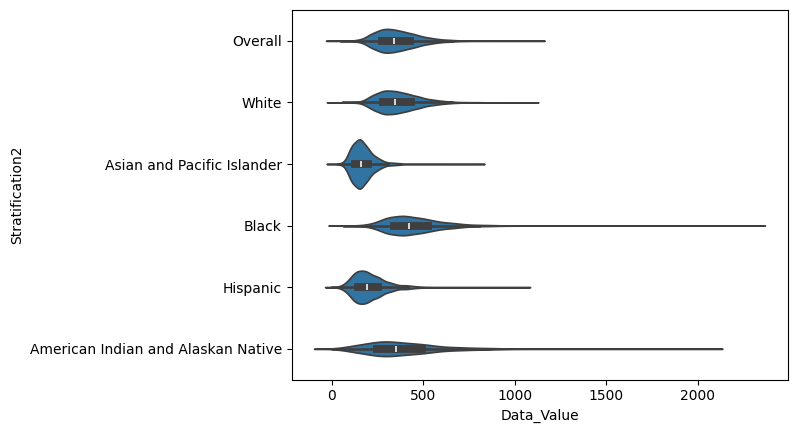

In [13]:
sns.violinplot(x='Data_Value', y='Stratification2', data=heart_df)

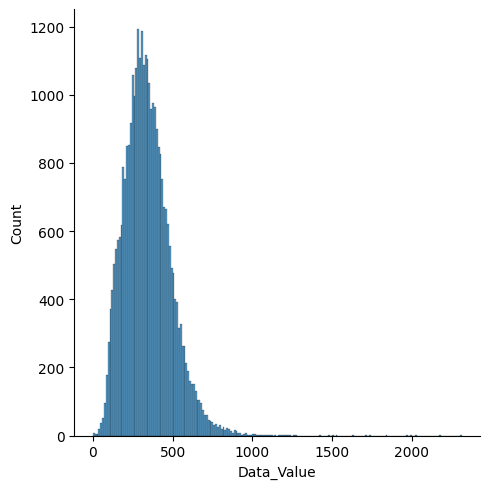

In [14]:
sns.displot(heart_df['Data_Value'])